<a href="https://colab.research.google.com/github/ChanderValasai/gender-pay-gap-audit/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/data-analysis-projects/pakistan-tech-pay-gap'
os.chdir(PROJECT_PATH)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/processed/cleaned_survey_2025.csv')
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(23112, 173)


In [4]:
summary = df.groupby('CountryGroup')['ConvertedCompYearly'].describe()
print(summary)

                 count          mean           std     min       25%      50%  \
CountryGroup                                                                    
Pakistan         112.0  15413.160714  21976.843762  1000.0   3494.25   8428.0   
Rest of World  23000.0  96384.277261  95239.876076  1000.0  42277.75  78000.0   

                     75%        max  
CountryGroup                         
Pakistan        19022.25   175581.0  
Rest of World  123993.00  2000000.0  


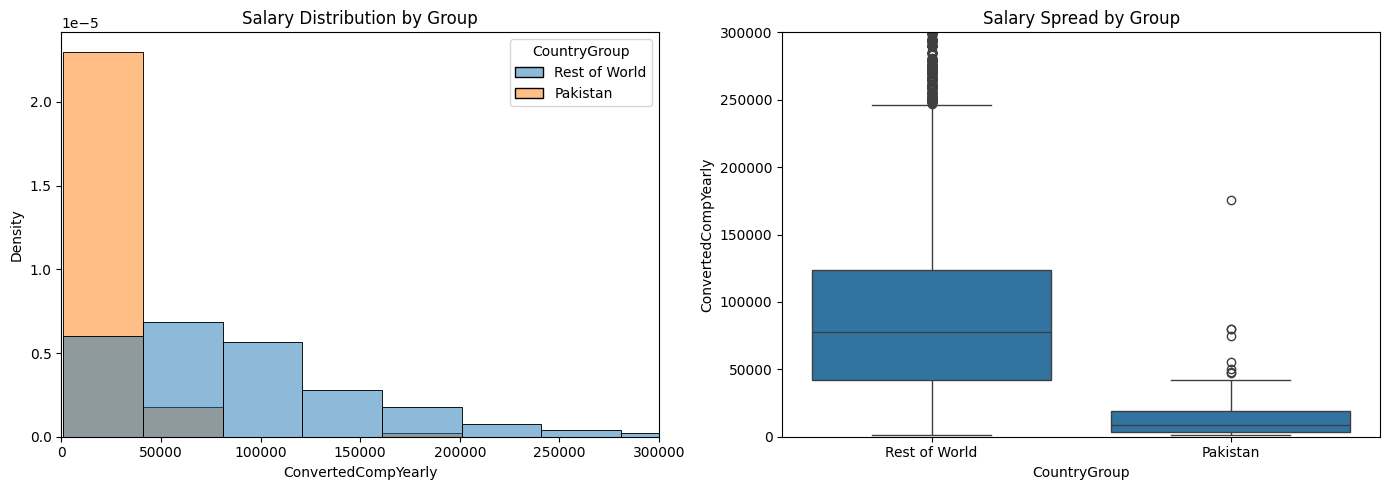

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='ConvertedCompYearly', hue='CountryGroup',
             stat='density', common_norm=False, bins=50, ax=axes[0])
axes[0].set_title('Salary Distribution by Group')
axes[0].set_xlim(0, 300000)  # zoom in, tail is very long

sns.boxplot(data=df, x='CountryGroup', y='ConvertedCompYearly', ax=axes[1])
axes[1].set_title('Salary Spread by Group')
axes[1].set_ylim(0, 300000)

plt.tight_layout()
plt.show()

Pakistan: skewness = 4.26
Rest of World: skewness = 5.23


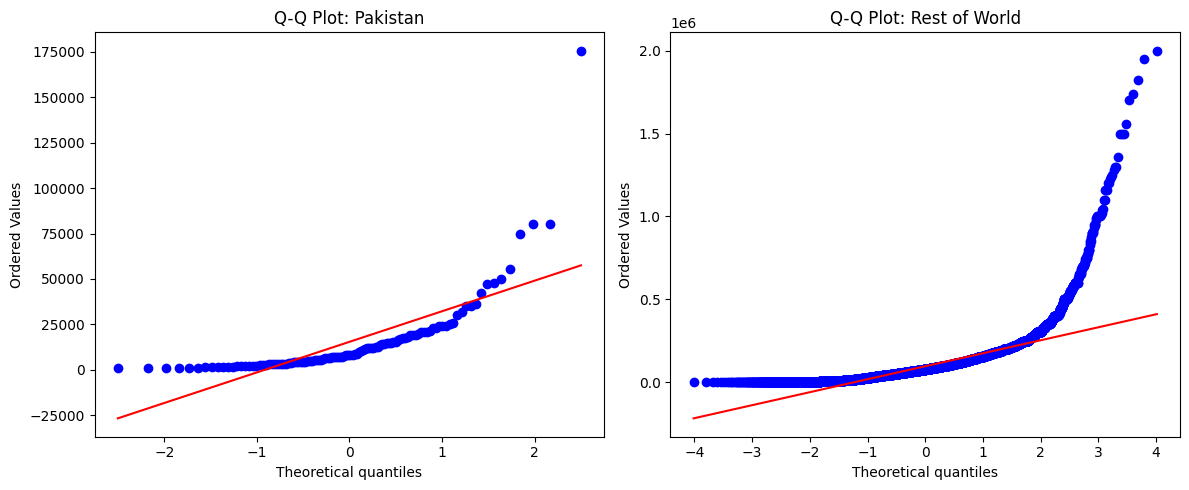

In [6]:
from scipy import stats

for group in ['Pakistan', 'Rest of World']:
    data = df[df['CountryGroup'] == group]['ConvertedCompYearly']
    skewness = stats.skew(data)
    print(f"{group}: skewness = {skewness:.2f}")

# Q-Q plots to visually check normality
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, group in zip(axes, ['Pakistan', 'Rest of World']):
    data = df[df['CountryGroup'] == group]['ConvertedCompYearly']
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {group}')
plt.tight_layout()
plt.show()

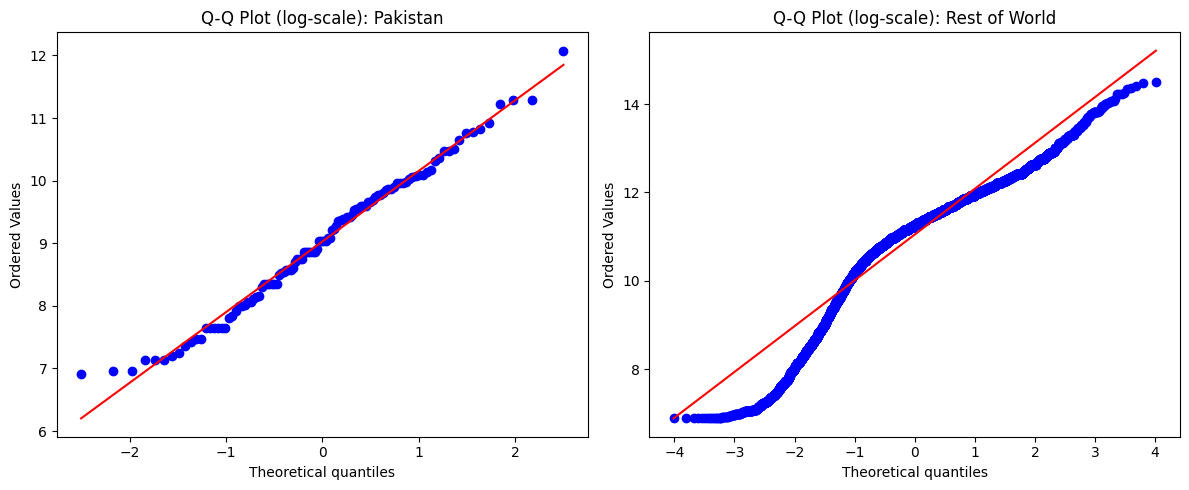

In [8]:
import numpy as np

df['LogComp'] = np.log(df['ConvertedCompYearly'])  # need: import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, group in zip(axes, ['Pakistan', 'Rest of World']):
    data = df[df['CountryGroup'] == group]['LogComp']
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot (log-scale): {group}')
plt.tight_layout()
plt.show()

## EDA Summary

**Descriptive Statistics (ConvertedCompYearly, USD)**

| Group | n | Mean | Median | Std | Min | Max |
|---|---|---|---|---|---|---|
| Pakistan | 112 | $15,413 | $8,428 | $21,977 | $1,000 | $175,581 |
| Rest of World | 23,000 | $96,384 | $78,000 | $95,240 | $1,000 | $2,000,000 |

**Observed raw gap:** Pakistan's median compensation is ~9x lower than Rest of World's ($8,428 vs. $78,000).
The mean gap (~6x) is smaller than the median gap, consistent with strong right-skew in both groups.

**Important caveat — do not over-read this yet:**
- This is the *unadjusted* gap. It has not been controlled for experience (YearsCode) or role, which is
  the entire point of Phase 6-7.
- This compares *nominal USD compensation*, not purchasing power. Given large cost-of-living differences
  between Pakistan and the mostly higher-income countries in "Rest of World," a substantial nominal gap is
  expected on its own and does not by itself indicate unfairness or discrimination. This distinction —
  nominal comparison vs. purchasing-power-adjusted comparison — will be stated explicitly in the final report.

**Distribution Shape**

- Both groups are heavily right-skewed (visible in histograms and boxplots — long upper tails, many
  high-end outliers particularly in Rest of World).
- Q-Q plots on raw values show clear deviation from normality for both groups, most pronounced at the
  upper tail.
- Log-transforming `ConvertedCompYearly` substantially improves normality for Pakistan (log Q-Q plot
  closely hugs the theoretical line). Rest of World remains moderately non-normal even on a log scale
  (residual S-curve, heavier tails than a true normal distribution), though with n=23,000 the Central
  Limit Theorem makes this less of a concern for mean-based tests.
- Variances are highly unequal between groups (Rest of World std ≈ $95,240 vs. Pakistan std ≈ $21,977),
  ruling out a standard Student's t-test, which assumes equal variance.

**Methodological Decision for Hypothesis Testing (Phase 6)**

Given non-normality (especially in the smaller Pakistan group, n=112) and unequal variances, three tests
will be run in parallel rather than relying on a single method:
1. Welch's t-test on raw values (does not assume equal variance)
2. Welch's t-test on log-transformed values (addresses skew directly)
3. Mann-Whitney U test (non-parametric, makes no distributional assumption — used as a robustness check)

Agreement across all three would give strong confidence in the conclusion; disagreement would need to be
investigated and reported transparently rather than cherry-picked.

**What remains:** formal hypothesis testing (Phase 6), followed by confounder-adjusted analysis controlling
for experience (Phase 7) — the unadjusted gap above cannot yet answer our core research question.